# Loading all of the data 

In [2]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import glob, os, re

results_root = os.path.expanduser('~/ParaToric/results')
h5_files = sorted(glob.glob(f'{results_root}/h_sweep/L*/etc_h_sweep/lattice*/simulation_data.h5'))

data = {}
for f in h5_files:
    m = re.search(r'_L=(\d+)_', f)
    L = int(m.group(1))
    with h5py.File(f, 'r') as h:
        data[L] = {k: h[k][...] for k in h.keys()}

Ls = sorted(data.keys())
print(f"Loaded data for L = {Ls}")
print(f"h values: {data[Ls[0]]['hs']}")

Loaded data for L = [4, 6, 8, 10, 12]
h values: [0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55]


# Binder ratio overlay (find h_c)

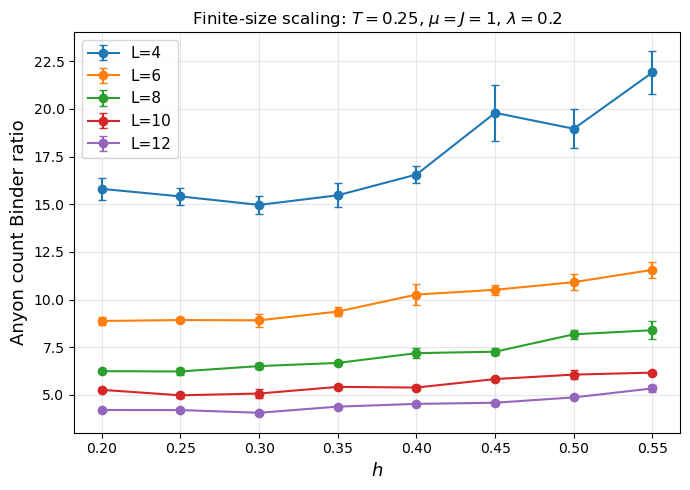

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))

for L in Ls:
    h_vals = data[L]['hs']
    binder = data[L]['anyon_count__binder']
    binder_err = data[L]['anyon_count__binder_error']
    ax.errorbar(h_vals, binder, yerr=binder_err,
                marker='o', label=f'L={L}', capsize=3)

ax.set_xlabel(r'$h$', fontsize=13)
ax.set_ylabel('Anyon count Binder ratio', fontsize=13)
ax.set_title(r'Finite-size scaling: $T=0.25$, $\mu=J=1$, $\lambda=0.2$', fontsize=12)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('binder_overlay.pdf', dpi=150)
plt.show()

# order parameter ⟨σˣ⟩ overlay

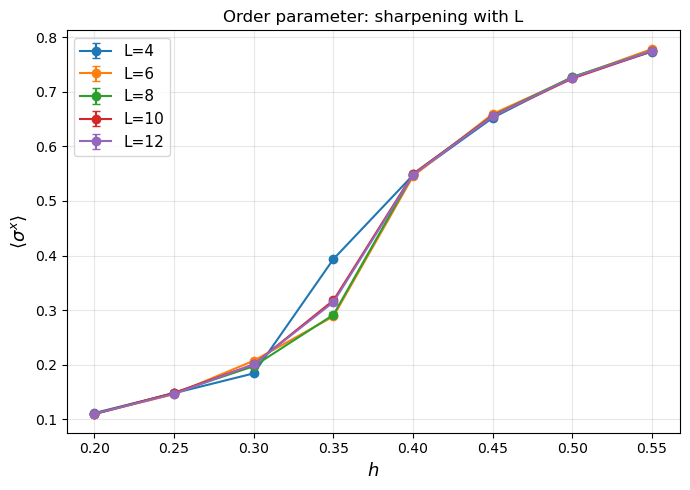

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))

for L in Ls:
    h_vals = data[L]['hs']
    sigma_x = data[L]['sigma_x_']
    err = data[L]['sigma_x__error']
    ax.errorbar(h_vals, sigma_x, yerr=err,
                marker='o', label=f'L={L}', capsize=3)

ax.set_xlabel(r'$h$', fontsize=13)
ax.set_ylabel(r'$\langle \sigma^x \rangle$', fontsize=13)
ax.set_title('Order parameter: sharpening with L', fontsize=12)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('sigma_x_overlay.pdf', dpi=150)
plt.show()

# Anyon density overlay

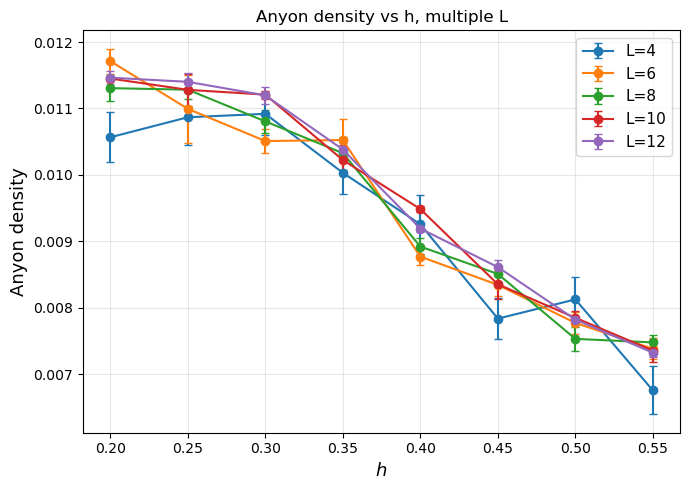

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))

for L in Ls:
    h_vals = data[L]['hs']
    rho = data[L]['anyon_density_']
    err = data[L]['anyon_density__error']
    ax.errorbar(h_vals, rho, yerr=err,
                marker='o', label=f'L={L}', capsize=3)

ax.set_xlabel(r'$h$', fontsize=13)
ax.set_ylabel('Anyon density', fontsize=13)
ax.set_title('Anyon density vs h, multiple L', fontsize=12)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('anyon_density_overlay.pdf', dpi=150)
plt.show()

# σˣ Binder ratio

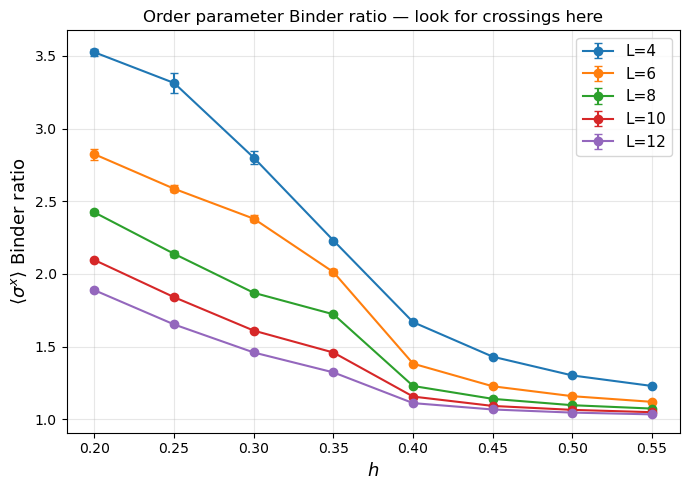

In [6]:
# Plot the sigma_x Binder ratio, which should also show crossings at the critical point


fig, ax = plt.subplots(figsize=(7, 5))

for L in Ls:
    h_vals = data[L]['hs']
    binder = data[L]['sigma_x__binder']
    binder_err = data[L]['sigma_x__binder_error']
    ax.errorbar(h_vals, binder, yerr=binder_err,
                marker='o', label=f'L={L}', capsize=3)

ax.set_xlabel(r'$h$', fontsize=13)
ax.set_ylabel(r'$\langle\sigma^x\rangle$ Binder ratio', fontsize=13)
ax.set_title('Order parameter Binder ratio — look for crossings here', fontsize=12)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('sigma_x_binder_overlay.pdf', dpi=150)
plt.show()

# σᶻ vs h

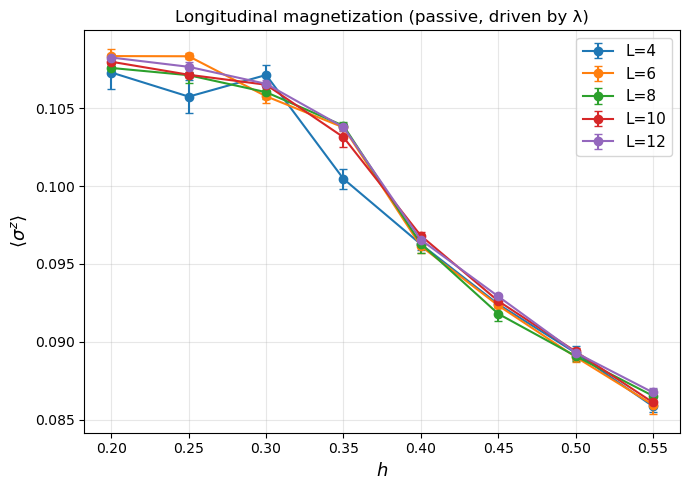

In [7]:
# Plot the sigma_z, which should be small but nonzero in the topological phase and grow in the trivial phase, with a sharper transition for larger L
fig, ax = plt.subplots(figsize=(7, 5))

for L in Ls:
    h_vals = data[L]['hs']
    sz = data[L]['sigma_z_']
    err = data[L]['sigma_z__error']
    ax.errorbar(h_vals, sz, yerr=err,
                marker='o', label=f'L={L}', capsize=3)

ax.set_xlabel(r'$h$', fontsize=13)
ax.set_ylabel(r'$\langle\sigma^z\rangle$', fontsize=13)
ax.set_title('Longitudinal magnetization (passive, driven by λ)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('sigma_z_overlay.pdf', dpi=150)
plt.show()

# Energy ⟨H⟩ vs h

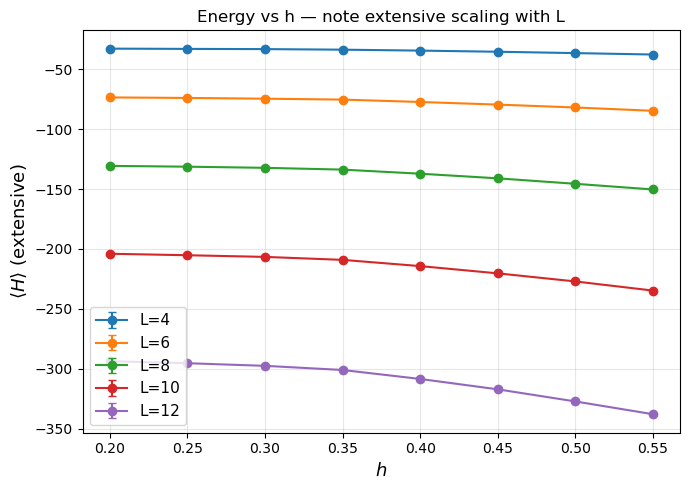

In [8]:
# Plot the energy, which should show a sharper kink at the transition for larger L, and also scale extensively with L
fig, ax = plt.subplots(figsize=(7, 5))

for L in Ls:
    h_vals = data[L]['hs']
    energy = data[L]['energy_']
    err = data[L]['energy__error']
    ax.errorbar(h_vals, energy, yerr=err,
                marker='o', label=f'L={L}', capsize=3)

ax.set_xlabel(r'$h$', fontsize=13)
ax.set_ylabel(r'$\langle H \rangle$ (extensive)', fontsize=13)
ax.set_title('Energy vs h — note extensive scaling with L', fontsize=12)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('energy_overlay.pdf', dpi=150)
plt.show()

# Energy per site (intensive)

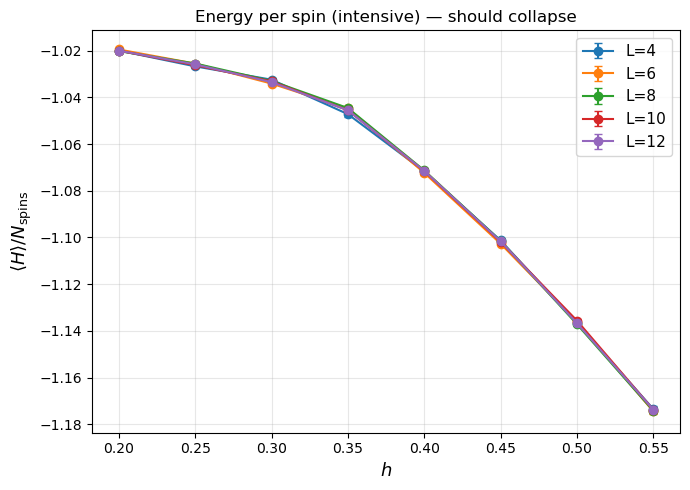

In [9]:
# Plot the energy per spin, which should show a sharper kink at the transition for larger L, but also scale intensively and thus collapse for different L
fig, ax = plt.subplots(figsize=(7, 5))

for L in Ls:
    h_vals = data[L]['hs']
    N_spins = 2 * L * L  # edges = 2L^2 on square lattice with periodic BC
    energy_density = data[L]['energy_'] / N_spins
    err = data[L]['energy__error'] / N_spins
    ax.errorbar(h_vals, energy_density, yerr=err,
                marker='o', label=f'L={L}', capsize=3)

ax.set_xlabel(r'$h$', fontsize=13)
ax.set_ylabel(r'$\langle H \rangle / N_\mathrm{spins}$', fontsize=13)
ax.set_title('Energy per spin (intensive) — should collapse', fontsize=12)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('energy_per_site_overlay.pdf', dpi=150)
plt.show()

# σˣ autocorrelation time

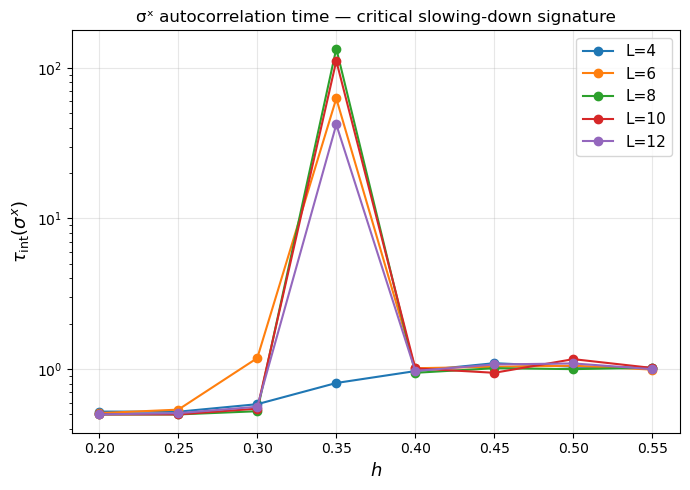

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))

for L in Ls:
    h_vals = data[L]['hs']
    tau = data[L]['sigma_x__int_ac_time']
    ax.plot(h_vals, tau, marker='o', label=f'L={L}')

ax.set_xlabel(r'$h$', fontsize=13)
ax.set_ylabel(r'$\tau_{\mathrm{int}}(\sigma^x)$', fontsize=13)
ax.set_title('σˣ autocorrelation time — critical slowing-down signature', fontsize=12)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.yscale('log')  # log scale because peaks can be huge
plt.tight_layout()
plt.savefig('sigma_x_autocorr_overlay.pdf', dpi=150)
plt.show()

# Anyon density Binder ratio

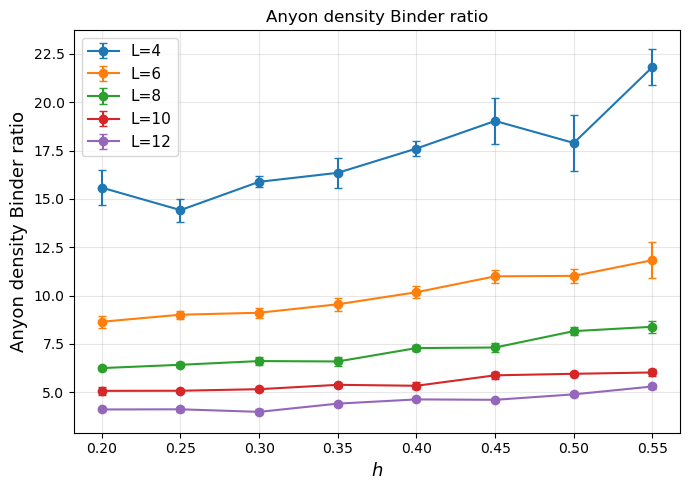

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))

for L in Ls:
    h_vals = data[L]['hs']
    binder = data[L]['anyon_density__binder']
    binder_err = data[L]['anyon_density__binder_error']
    ax.errorbar(h_vals, binder, yerr=binder_err,
                marker='o', label=f'L={L}', capsize=3)

ax.set_xlabel(r'$h$', fontsize=13)
ax.set_ylabel('Anyon density Binder ratio', fontsize=13)
ax.set_title('Anyon density Binder ratio', fontsize=12)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('anyon_density_binder_overlay.pdf', dpi=150)
plt.show()